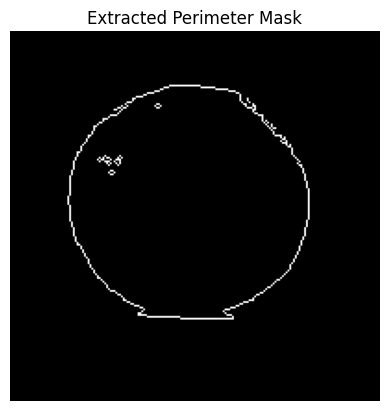

Roundness: 0.7572
Elongation: 1.0300
Average R: 248.3
Average G: 144.8
Average B: 45.9


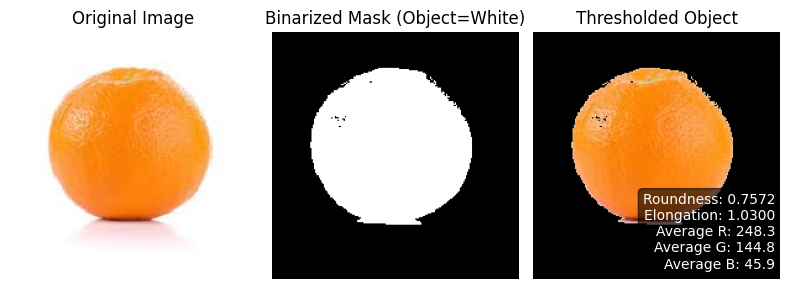

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# -----------------------------------------------------------
# -----------------------------------------------------------
def resize_nearest(img, new_h, new_w):
    old_h, old_w = img.shape[:2]
    row_idx = (np.linspace(0, old_h - 1, new_h)).astype(int)
    col_idx = (np.linspace(0, old_w - 1, new_w)).astype(int)
    # meshgrid for all pairs of row,col
    grid_y, grid_x = np.meshgrid(row_idx, col_idx, indexing='ij')
    # get the image at those coordinates
    return img[grid_y, grid_x]
# -----------------------------------------------------------
def compute_Roundness(mask):
    # Assume 'mask' is your binary object mask (dtype=bool or 0/1, shape (H,W)), where object=True/1
    # 1. Compute area
    area = np.sum(mask)

    # 2. Compute perimeter (Numpy only, 4-connectivity)
    # A pixel is counted as perimeter if it is object and has at least one neighbor that is background
    # Pad the mask to handle edges
    padded = np.pad(mask, pad_width=1, mode='constant', constant_values=0)

    # Get 4-connected neighbors
    neighbors = (
        ~padded[1:-1, 1:-1] &  # Not object itself (should not count pure background)
        (
            padded[:-2, 1:-1]   |  # above
            padded[2:, 1:-1]    |  # below
            padded[1:-1, :-2]   |  # left
            padded[1:-1, 2:]       # right
        )
    )
    # Now, perimeter mask: those pixels that are object and have at least one neighbor that's background
    perimeter_mask = (
        mask &
        (
            (~padded[:-2, 1:-1]) |
            (~padded[2:, 1:-1])  |
            (~padded[1:-1, :-2]) |
            (~padded[1:-1, 2:])
        )
    )
    perimeter = np.sum(perimeter_mask)

    # 3. Compute roundness
    if perimeter > 0:
        roundness = 4 * np.pi * area / (perimeter ** 2)
    else:
        roundness = 0

##    print(f"Area: {area}")
##    print(f"Perimeter: {perimeter}")
##    print(f"Roundness: {roundness:.4f}")
    # Visualize the perimeter mask
    plt.imshow(perimeter_mask, cmap='gray')
    plt.title("Extracted Perimeter Mask")
    plt.axis('off')
    plt.show()
    
    return roundness

# ---------------------------------------------------------------------------------------------
def compute_Elongation(mask):
    # Assume mask is your binary mask (bool/0-1), True for object pixels
    ys, xs = np.where(mask)  # Object pixel coordinates

    # Stack as (N, 2) array
    coords = np.column_stack((xs, ys))

    # Compute covariance matrix of coordinates
    cov = np.cov(coords, rowvar=False)

    # Compute eigenvalues (variances along principal axes)
    eigvals = np.linalg.eigvalsh(cov)  # Returns sorted eigenvalues

    # Major and minor axes (standard deviations)
    if eigvals[0] > 0:
        elongation = np.sqrt(eigvals[1]) / np.sqrt(eigvals[0])
    else:
        elongation = np.inf

##    print(f"Eigenvalues: {eigvals}")
##    print(f"Elongation: {elongation:.3f}")
    return elongation
# ---------------------------------------------------------------------------------------------
# ---------------------------------------------------------------------------------------------
# ---------------------------------------------------------------------------------------------
img_raw = plt.imread('images/orange/image1.bmp')  # Loads with shape (H,W,3) or (H,W,4)
if img_raw.dtype != np.uint8:
    img_raw = (img_raw * 255).astype(np.uint8)

# Remove alpha channel if present
if img_raw.shape[2] == 4:
    img_raw = img_raw[:, :, :3]

img = resize_nearest(img_raw, 200, 200)    

# Convert to grayscale
gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

# Otsu's threshold (NumPy implementation)
hist, bin_edges = np.histogram(gray.ravel(), bins=256, range=(0, 256))
total = gray.size
current_max, threshold = 0, 0
sum_total = np.dot(np.arange(256), hist)
sum_background, weight_background = 0.0, 0.0

for i in range(256):
    weight_background += hist[i]
    if weight_background == 0:
        continue
    weight_foreground = total - weight_background
    if weight_foreground == 0:
        break
    sum_background += i * hist[i]
    mean_background = sum_background / weight_background
    mean_foreground = (sum_total - sum_background) / weight_foreground
    between_var = (weight_background * weight_foreground *
                   (mean_background - mean_foreground) ** 2)
    if between_var > current_max:
        current_max = between_var
        threshold = i

# Apply Otsu threshold
mask = gray < threshold
# ---------------------------------------------
roundness = compute_Roundness(mask)
print(f"Roundness: {roundness:.4f}")

elongation = compute_Elongation(mask)
print(f"Elongation: {elongation:.4f}")
# ---------------------------------------------
# Create binarized image: white (255) for object, black (0) for background
binary_mask = np.zeros_like(gray, dtype=np.uint8)
binary_mask[mask] = 255
# ---------------------------------------------
# Apply mask to color image, set background to black
result = np.zeros_like(img)
result[mask] = img[mask]

object_pixels = img[mask]           # Shape: (N_object_pixels, 3)
if object_pixels.size > 0:
    avg_r, avg_g, avg_b = object_pixels.mean(axis=0)
    print(f"Average R: {avg_r:.1f}")
    print(f"Average G: {avg_g:.1f}")
    print(f"Average B: {avg_b:.1f}")
else:
    print("No object pixels found!")

# Plot original and thresholded result
plt.figure(figsize=(8, 4))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Binarized Mask (Object=White)')
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Thresholded Object')
plt.imshow(result)
plt.axis('off')

# Add text box with metrics
info = (
    f"Roundness: {roundness:.4f}\n"
    f"Elongation: {elongation:.4f}\n"
    f"Average R: {avg_r:.1f}\n"
    f"Average G: {avg_g:.1f}\n"
    f"Average B: {avg_b:.1f}"
)
plt.gca().text(
    0.98, 0.03, info,
    fontsize=10, color='white', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round'),
    ha='right', va='bottom', transform=plt.gca().transAxes
)

plt.tight_layout()
plt.show()
# -----------------------------------------------------------

